# Denetimli Öğrenme - K-En Yakın Komşu (KNN) Kullanarak Sınıflandırma

## K-En Yakın Komşular Nedir?

Bu noktaya kadar, üç denetimli öğrenme algoritması hakkında konuştuk: doğrusal regresyon, lojistik regresyon ve destek vektör makineleri. Bu bölümde, K-En Yakın Komşular (KNN) olarak bilinen başka bir denetimli makine öğrenimi algoritmasına dalacağız.
KNN, önceki bölümlerde tartıştığımız diğer algoritmalara kıyasla oldukça basit bir algoritmadır. Çalışma şekli, sorgu örneğinin diğer eğitim örneklerine olan uzaklığını karşılaştırır ve K-en yakın komşuları (bu nedenle adı) seçer. Ardından, bu K komşu sınıflarının çoğunluğunu sorgu örneğinin tahmini olarak alır.
Şekil 9.1 bu konuyu güzel bir şekilde özetliyor. k = 3 olduğunda, dairenin en yakın üç komşusu iki kare ve bir üçgen. Basit çoğunluk kuralına göre, daire bir kare olarak sınıflandırılır. Eğer k = 5 ise, en yakın beş komşu iki kare ve üç üçgen olacaktır. Dolayısıyla, daire bir üçgen olarak sınıflandırılır.

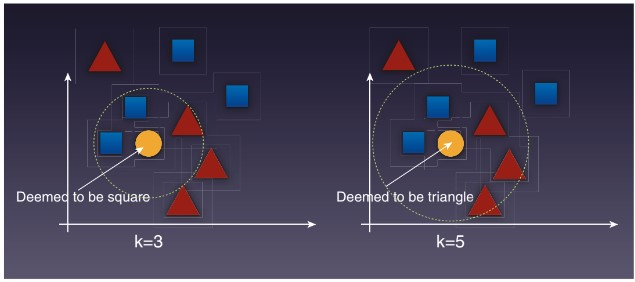

In [1]:
from IPython.display import Image

Image(filename='Figure-9.1.jpg')

**Şekil 9.1:** Bir noktanın sınıflandırılması, komşularının çoğunluğuna bağlıdır

**İpucu:** KNN bazen sınıflandırmanın yanı sıra regresyon için de kullanılır. Örneğin, K-en yakın komşuların sayısal hedefinin ortalamasını hesaplamak için kullanılabilir. Ancak, bu bölümde, daha yaygın kullanımı olan bir sınıflandırma algoritması olarak yalnızca bu kullanıma odaklanıyoruz.

## Python'da KNN'yi Uygulamak 

KNN'nin nasıl çalıştığını gördüğümüze göre, Python kullanarak sıfırdan KNN uygulamayı deneyelim. Her zamanki gibi, ihtiyacımız olan modülleri içe aktaralım:

In [2]:
import pandas as pd
import numpy as np
import operator
import seaborn as sns
import matplotlib.pyplot as plt

## Noktaları Çizmek

Bu örnekte, aşağıdaki verileri içeren knn.csv adlı bir dosyayı kullanacaksınız:

Önceki bölümlerde yaptığımız gibi, noktaları görselleştirmenin iyi bir yolu Seaborn kullanmaktır.

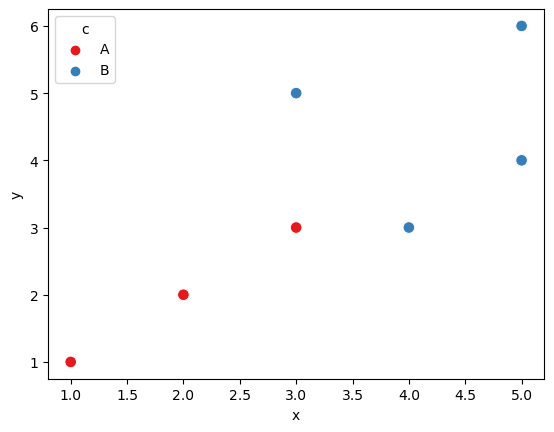

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    'x': [1, 2, 4, 3, 3, 5, 5],
    'y': [1, 2, 3, 3, 5, 6, 4],
    'c': ['A', 'A', 'B', 'A', 'B', 'B', 'B']
})

sns.scatterplot(x='x', y='y', hue='c', 
                palette='Set1', 
                data=data, s=70)
plt.show()


Şekil 9.2, çeşitli noktaların dağılımını gösterir. A sınıfına ait noktalar kırmızı olarak gösterilirken, B sınıfına ait olanlar mavi olarak gösterilir.

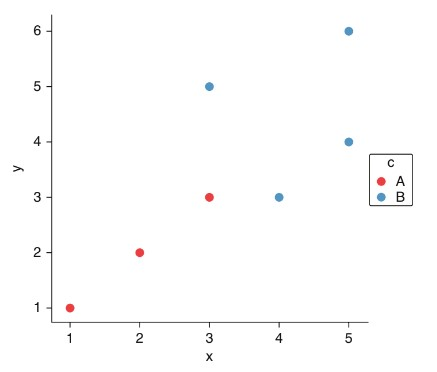

In [7]:
Image(filename='Figure-9.2.jpg')

**Şekil 9.2:** Noktaların görsel olarak çizimi

## Noktalar Arasındaki Mesafeyi Hesaplama 

Belirli bir noktanın en yakın komşusunu bulmak için, iki nokta arasındaki Öklid mesafesini hesaplamanız gerekir.

**İpucu:** Geometride, Öklid uzayı, iki boyutlu Öklid düzlemi, üç boyutlu Öklid geometrisi uzayını ve daha yüksek boyutlu benzer uzayları kapsar.

Burada, p ve q noktalarının koordinatları sırasıyla $p = (p_1, p_2, ..., p_n)$ ve $q = (q_1, q_2, ..., q_n)$, $p$ ve $q$ arasındaki mesafe aşağıdaki formülle verilir:

$$\text{distance}(p, q) = \sqrt{(q_1 - p_1)^2 + (q_2 - p_2)^2 + \ldots + (q_n - p_n)^2}$$

Bu formülü kullanarak, aşağıdaki gibi bir fonksiyon tanımlayabilirsiniz:

In [10]:
#---iki nokta arasındaki mesafeyi hesaplamak için---
def euclidean_distance(pt1, pt2, boyut):
    mesafe = 0
    for x in range(boyut):
        mesafe += np.square(pt1[x] - pt2[x])
    return np.sqrt(mesafe)

Öklid _ mesafe() işlevi, herhangi bir boyutta iki nokta arasındaki mesafeyi bulabilir. Bu örnekte, uğraştığımız noktalar 2D'dedir.

## KNN'yi uygulamak

Sıradaki adım, eğitim noktalarını, test noktasını ve k değerini alan knn() adlı bir işlevi tanımlamaktır.

In [11]:
#---kendi KNN modelimiz---
def knn(eğitim_noktaları, test_noktası, k):
    mesafeler = {}
    #---üzerinde çalıştığımız eksen sayısı---
    boyut = test_noktası.shape[1]
    #--her eğitim verisi noktası ile test verisi noktası arasındaki Öklid mesafesini hesaplama
    for x in range(len(eğitim_noktaları)):
        mesafe = euclidean_distance(test_noktası, eğitim_noktaları.iloc[x], boyut)
        #---her eğitim noktası için mesafeyi kaydet---
        mesafeler[x] = mesafe[0]
    #---mesafeleri sırala---
    sıralı_m = sorted(mesafeler.items(), key=operator.itemgetter(1))
    #---komşuları depolamak için---
    komşular = []
    #---en üst k komşuyu al---
    for x in range(k):
        komşular.append(sıralı_m[x][0])
    #---her bulunan komşu için, sınıfını bul---
    sınıf_sayacı = {}
    for x in range(len(komşular)):
        #---o belirli nokta için sınıfı bul---
        snf = eğitim_noktaları.iloc[komşular[x]][-1]
        if snf in sınıf_sayacı:
            sınıf_sayacı[snf] += 1
        else:
            sınıf_sayacı[snf] = 1
    #---sınıf_sayacını azalan sırada sırala---
    sıralı_sayac = sorted(sınıf_sayacı.items(), key=operator.itemgetter(1), reverse=True)
    #---en çok sayıda sınıfı ve bulunan komşuları döndür---
    return (sıralı_sayac[0][0], komşular)

Fonksiyon, test noktasının hangi sınıfa ait olduğunu ve en yakın k komşuların tüm indislerini döndürür.

## Tahminler Yapma

Artık knn() işlevi tanımlandığına göre, bazı tahminler yapabilirsiniz:

In [13]:
#---test seti---
test_set = [[3, 3.9]]
test = pd.DataFrame(test_set)
#---knn fonksiyonunu kullanarak tahmin yap---
snf, komşular = knn(data, test, 5)
print("Tahmin Edilen Sınıf: " + snf)

Tahmin Edilen Sınıf: B


Önceki kod örneği aşağıdaki çıktıyı verecektir:
    
    Tahmin Edilen Sınıf: B

## Farklı K Değerlerinin Görselleştirilmesi

Çeşitli k değerlerinin etkisini görselleştirmek faydalıdır. Aşağıdaki kod parçacığı, k değerlerine dayalı olarak test noktası etrafında bir dizi konsantrik daire çizer. K değerleri 7 ile 1 arasında, -2 aralıklarla değişir.

k =  7
Sınıf B
Komşular
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
6  5  4  B
1  2  2  A
5  5  6  B
0  1  1  A
k =  5
Sınıf B
Komşular
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
6  5  4  B
1  2  2  A
k =  3
Sınıf B
Komşular
   x  y  c
3  3  3  A
4  3  5  B
2  4  3  B
k =  1
Sınıf A
Komşular
   x  y  c
3  3  3  A


C:\Users\Furkan\anaconda3\Lib\site-packages\matplotlib\transforms.py:2068: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  self._mtx[0, 0] *= sx
C:\Users\Furkan\anaconda3\Lib\site-packages\matplotlib\transforms.py:2069: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  self._mtx[0, 1] *= sx
C:\Users\Furkan\anaconda3\Lib\site-packages\matplotlib\transforms.py:2070: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  self._mtx[0, 2] *= sx
C:\Users\Furkan\anaconda3\Lib\site-packages\matplotlib\transforms.py:2071: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  self._mtx[1, 0] *= sy
C:\Users\Furkan\anaconda3\Lib\si

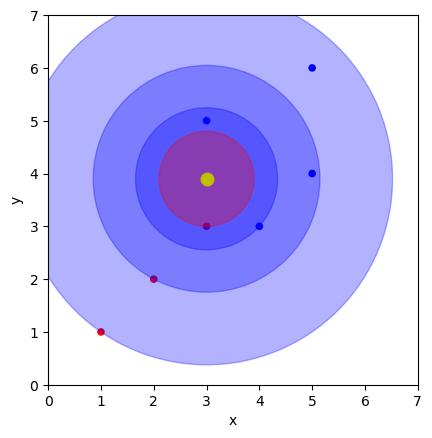

In [14]:
#---serpme grafiği için renk haritasını oluştur---
#---'c' sütunu A ise, Kırmızı kullan, değilse Mavi kullan---
renkler = ['r' if i == 'A' else 'b' for i in data['c']]
ax = data.plot(kind='scatter', x='x', y='y', c=renkler)
plt.xlim(0, 7)
plt.ylim(0, 7)
#---test noktasını çiz---
plt.plot(test_set[0][0], test_set[0][1], "yo", markersize='9')
for k in range(7, 0, -2):
    snf, komşular = knn(data, test, k)
    print("============")
    print("k = ", k)
    print("Sınıf", snf)
    print("Komşular")
    print(data.iloc[komşular])
    en_uzak_nokta = data.iloc[komşular].tail(1)
    #---test noktası ile en uzak nokta arasında bir daire çiz---
    yarıçap = euclidean_distance(test, en_uzak_nokta.iloc[0], 2)
    #---Sınıflandırma A ise çizgiyi kırmızı olarak göster,
    #değilse çizgiyi mavi olarak göster---
    c = 'r' if snf == 'A' else 'b'
    daire = plt.Circle((test_set[0][0], test_set[0][1]), yarıçap, color=c, alpha=0.3)
    ax.add_patch(daire)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Önceki kod örneği aşağıdaki çıktıyı verecektir:

Şekil 9.3, k-değeri değişen serinin, test noktasının etrafında merkezlenmiş daireleri göstermektedir. En içteki daire, k = 1 için, bir sonraki dış halka ise k = 3 için ve böyle devam eder. Görebileceğiniz gibi, eğer k = 1 ise, daire kırmızıdır, bu da sarı noktanın A sınıfı olarak sınıflandırıldığını gösterir. Eğer daire mavi ise, bu sarı noktanın B sınıfı olarak sınıflandırıldığını gösterir. Bu, dış üç dairede açıkça görülebilir.

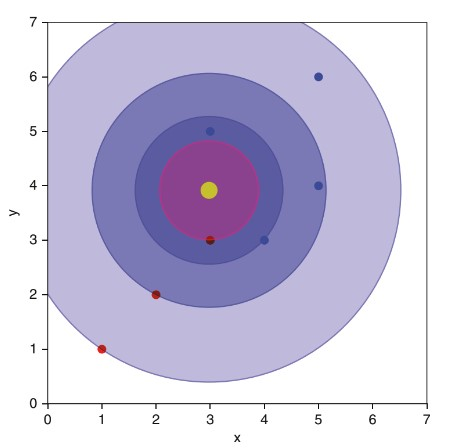

In [15]:
Image(filename='Figure-9.3.jpg')

**Şekil 9.3:** Sarı noktanın farklı k değerlerine göre sınıflandırılması

## Scikit-Learn'ün KNeighborsClassifier Sınıfının Kullanımı için KNN

Şimdi KNN'nin nasıl çalıştığını ve Python'da nasıl elle uygulanabileceğini gördük, şimdi Scikit-learn tarafından sağlanan uygulamayı kullanalım.

Aşağıdaki kod parçacığı, Iris veri kümesini yükler ve bir dağılım grafiği kullanarak görselleştirir:

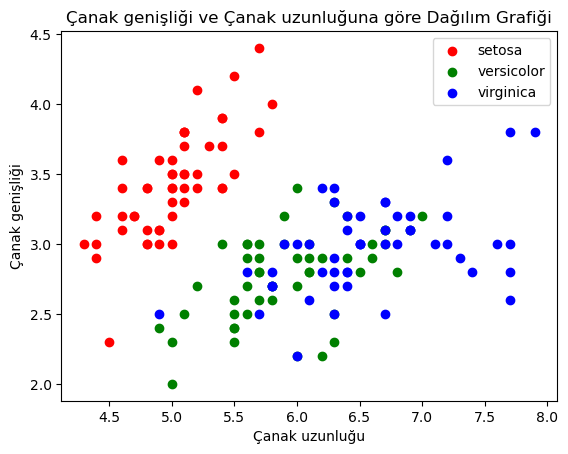

In [17]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
from sklearn import svm, datasets
import matplotlib.pyplot as plt

# Iris veri kümesini yükle
iris = datasets.load_iris()
X = iris.data[:, :2] # ilk iki özelliği al
y = iris.target

#---noktaları çiz---
renkler = ['red', 'green', 'blue']
for renk, i, hedef in zip(renkler, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=renk, label=hedef)

plt.xlabel('Çanak uzunluğu')
plt.ylabel('Çanak genişliği')
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('Çanak genişliği ve Çanak uzunluğuna göre Dağılım Grafiği')
plt.show()

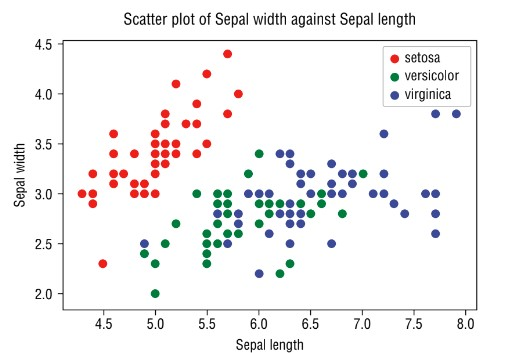

In [18]:
Image(filename='Figure-9.4.jpg')

**Şekil 9.4:** Çanak genişliğini Çanak uzunluğuna karşı bir dağılım grafiğinde gösterme

Şekil 9.4, Çanak genişliğini Çanak uzunluğuna karşı dağılım grafiğini göstermektedir.

## Farklı K Değerlerini Keşfetmek

Şimdi Scikit-learn'ün KNeighborsClassifier sınıfını kullanarak Iris veri kümesinde KNN ile bir model eğitmek için yardımcı olabiliriz. Başlangıç olarak, k değerini 1 olarak kullanalım:

(array([0, 1, 2]), array([50, 60, 40], dtype=int64))


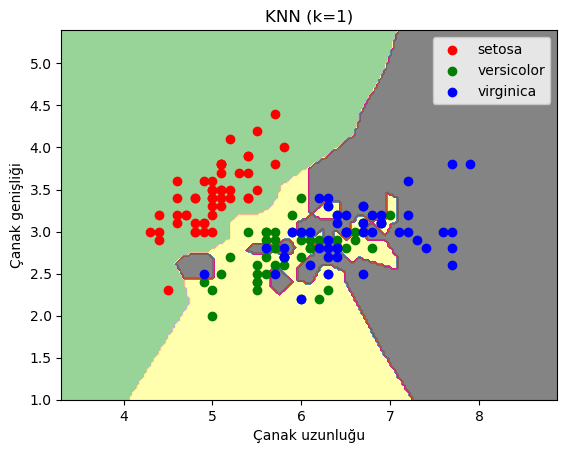

In [19]:
from sklearn.neighbors import KNeighborsClassifier
k = 1
#---öğrenme modelini başlat---
knn = KNeighborsClassifier(n_neighbors=k)
#---modeli eğit---
knn.fit(X, y)
#---birinci özellik için min ve max---
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
#---ikinci özellik için min ve max---
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
#---örgüdeki adım büyüklüğü---
h = (x_max / x_min) / 100
#---xx, yy'deki her bir nokta için tahminler yap---
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
#---sonucu bir renk haritası kullanarak çiz---
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, cmap=plt.cm.Accent, alpha=0.8)
#---eğitim noktalarını çiz---
renkler = ['red', 'green', 'blue']
for renk, i, hedef in zip(renkler, [0, 1, 2], iris.target_names):
    plt.scatter(X[y==i, 0], X[y==i, 1], color=renk, label=hedef)
plt.xlabel('Çanak uzunluğu')
plt.ylabel('Çanak genişliği')
plt.title(f'KNN (k={k})')
plt.legend(loc='best', shadow=False, scatterpoints=1)
tahminler = knn.predict(X)
#---tahminlere dayalı sınıflandırmalar---
print(np.unique(tahminler, return_counts=True))

Önceki kod parçacığı, x- ve y-eksenleri üzerinde yayılmış noktalardan oluşan bir meshgrid (dikdörtgen bir değer ağı) oluşturur. Her nokta daha sonra tahmin için kullanılır ve sonuç bir renk haritası kullanılarak çizilir.

Şekil 9.5, k = 1 kullanılarak sınıflandırma sınırını göstermektedir. k = 1 için, tahminlerinizi yalnızca bir tek örneğe - en yakın komşunuzunuz - dayanarak gerçekleştirirsiniz. Bu, tahminlerinizi çeşitli bozulmalara, aykırı değerlere, yanlış etiketlemelere vb. karşı çok duyarlı hale getirir. Genel olarak, k = 1 ayarlamanın genellikle aşırı uyuma yol açtığı ve sonucunda tahminlerinizin genellikle çok doğru olmadığı görülür.

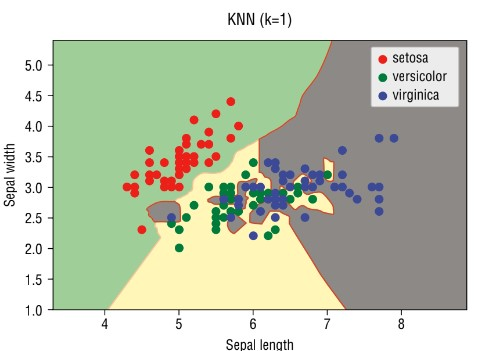

In [20]:
Image(filename='Figure-9.5.jpg')

**Şekil 9.5:** k = 1'e dayalı sınıflandırma sınırı

Makine öğreniminde overfitting, eğittiğiniz modelin eğitim verilerine çok iyi uyması anlamına gelir. Bu durum, eğitim sürecinde tüm gürültü ve dalgalanmaların alınması durumunda gerçekleşir. Basitçe söylemek gerekirse, bu, modelinizin tüm verilerinizi mükemmel bir şekilde uyacak şekilde çok fazla çaba gösterdiği anlamına gelir. Aşırı uydurmanın temel sorunu, aşırı uyumlu bir modelin yeni, görünmemiş verilerle iyi çalışmamasıdır.

**İpucu:** Öte yandan, yetersiz uydurma, bir makine öğrenme modelinin verilerin temel eğilimini doğru bir şekilde yakalayamadığında ortaya çıkar. Özellikle, model verileri yeterince iyi uyum sağlamaz.
Şekil 9.6, aşırı uydurma, yetersiz uydurma ve genel olarak iyi uyumun anlaşılmasının kolay bir yolunu gösterir.

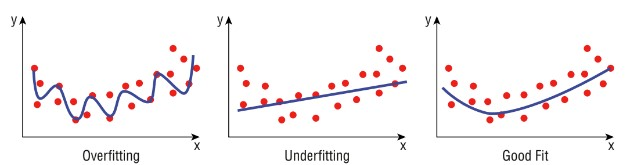

In [21]:
Image(filename='Figure-9.6.jpg')

**Şekil 9.6:** Aşırı uydurma, yetersiz uydurma ve iyi uyuşmanın kavramını anlama

KNN için k değerini daha yüksek bir değere ayarlamak, tahminlerinizi verilerinizdeki gürültülere karşı daha sağlam hale getirme eğilimindedir.
Aynı kod parçacığını kullanarak, k değerlerini değiştirelim. Şekil 9.7, dört farklı k değerine dayalı sınıflandırmaları göstermektedir.

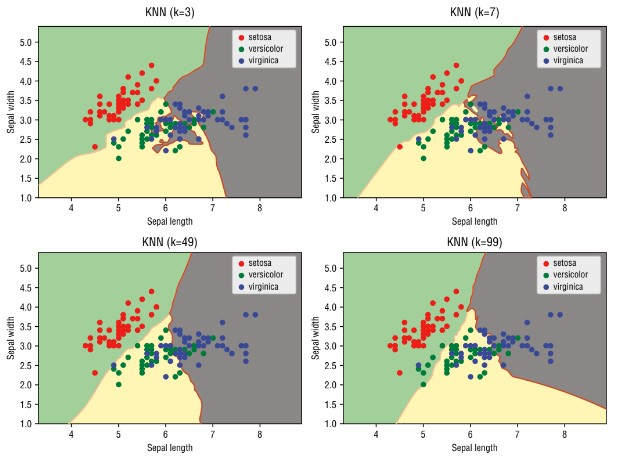

In [22]:
Image(filename='Figure-9.7.jpg')

**Şekil 9.7:** K değerlerinin değişimlerinin etkileri

k değeri arttıkça, sınırlar daha düz hale gelir. Ancak bu, daha fazla noktanın yanlış sınıflandırılacağı anlamına gelir. K büyük bir değere ulaştığında, yetersiz uyum gerçekleşir.
KNN ile ana sorun, hangi k değerinin kullanılacağının ideal değerini nasıl bulacağınızdır.

## Çapraz Doğrulama

Önceki birkaç bölümde, veri kümemizi iki ayrı sete böldüğümüzü gördünüz - biri eğitim için, diğeri test için. Ancak, veri kümenizdeki veriler eşit şekilde dağılmayabilir ve sonuç olarak test setiniz çok basit veya çok zor olabilir, bu da modelinizin iyi çalışıp çalışmadığını çok zorlaştırır.
Eğitim için bir kısmını ve test için bir kısmını kullanmak yerine, veriyi k katına bölebilir ve modelleri k kez eğitebilirsiniz, eğitim ve test kümelerini döndürerek. Böylece, her veri noktası artık eğitim ve test için kullanılıyor olur.

**İpucu:** K-folds içindeki k'yi KNN'deki k ile karıştırmayın - bunlar ilişkili değildir.

Şekil 9.8, beş katmana (bloğa) bölünmüş bir veri kümesini göstermektedir. İlk çalışmada, bloklar 1, 2, 3 ve 4 modeli eğitmek için kullanılacaktır. Blok 0, modeli test etmek için kullanılacaktır. Bir sonraki çalışmada, bloklar 0, 2, 3 ve 4 eğitim için kullanılacak ve blok 1 test için kullanılacaktır, ve böyle devam eder.

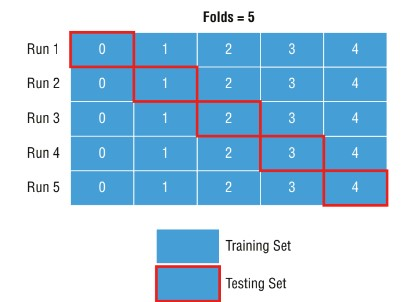

In [24]:
Image(filename='Figure-9.8.jpg')

**Şekil 9.8:** Çapraz doğrulama nasıl çalışır.

Her çalışmanın sonunda, model puanlanır. K çalışmasının sonunda, puan ortalanır. Bu ortalama puan, algoritmanızın ne kadar iyi performans gösterdiğine dair iyi bir gösterge sağlar.

**İpucu:** Çapraz doğrulamanın amacı, modelinizi eğitmek değil, model kontrolü içindir. Çapraz doğrulama, farklı makine öğrenimi algoritmalarını karşılaştırmak için gereken durumlarda yararlıdır ve veri kümesiyle nasıl performans gösterdiklerini görmek için kullanılır. Bir kez algoritma seçildiğinde, modeli eğitmek için tüm verileri kullanacaksınız.

## Parametre Ayarlama K

Çapraz doğrulamayı anladığınıza göre, şimdi onu Iris veri kümemizde kullanalım. Dört özellik kullanarak modeli eğiteceğiz ve aynı zamanda 10 katlı çapraz doğrulamayı veri kümesinde kullanacağız. Her k değeri için bunu yapacağız:

In [29]:
from sklearn.model_selection import cross_val_score
#---cv (çapraz doğrulama) puanlarını tutar---
cv_puanları = []
#---tüm özellikleri kullan---
X = iris.data[:, :4]
y = iris.target
#---kat sayısı---
katlar = 10
#---KNN için tek sayıların listesi oluşturuluyor---
ks = list(range(1, int(len(X) * ((katlar - 1) / katlar))))
#---3'ün katları çıkarılıyor---
ks = [k for k in ks if k % 3 != 0]
#---k-kat çapraz doğrulama yapılıyor---
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    #---çapraz doğrulama yapılır ve ortalama doğruluk döndürülür---
    puanlar = cross_val_score(knn, X, y, cv=katlar, scoring='accuracy')
    ortalama = puanlar.mean()
    cv_puanları.append(ortalama)
    print(k, ortalama)

1 0.96
2 0.9533333333333334
4 0.9666666666666666
5 0.9666666666666668
7 0.9666666666666668
8 0.9666666666666668
10 0.9666666666666668
11 0.9666666666666668
13 0.9800000000000001
14 0.9733333333333334
16 0.9733333333333334
17 0.9733333333333334
19 0.9733333333333334
20 0.9800000000000001
22 0.9666666666666666
23 0.9733333333333334
25 0.9666666666666666
26 0.96
28 0.9533333333333334
29 0.9533333333333334
31 0.9466666666666667
32 0.9466666666666667
34 0.9466666666666667
35 0.9466666666666667
37 0.9466666666666667
38 0.9466666666666667
40 0.9533333333333334
41 0.9533333333333334
43 0.9466666666666667
44 0.9400000000000001
46 0.9333333333333333
47 0.9333333333333333
49 0.9400000000000001
50 0.9266666666666667
52 0.9333333333333333
53 0.9333333333333333
55 0.9333333333333333
56 0.9066666666666666
58 0.9133333333333334
59 0.9200000000000002
61 0.9199999999999999
62 0.9066666666666666
64 0.9
65 0.9
67 0.8866666666666667
68 0.8800000000000001
70 0.8866666666666667
71 0.8866666666666667
73 0.893

Scikit-learn kütüphanesi, otomatik olarak çapraz doğrulama yapmanızı sağlayan ve istediğiniz metrikleri (örneğin, doğruluk) döndüren cross_val_score() işlevini sağlar.

Çapraz doğrulama kullanırken, herhangi bir zamanda, ((katlar-1) / katlar) * toplam_satırlar eğitim için kullanılabilir olacaktır. Bunun nedeni, (1/katlar) * toplam_satırların test için kullanılmasıdır.

KNN için uyulması gereken üç kural bulunmaktadır:
- k değeri, eğitim için satır sayısını aşamaz.
- k değeri tek sayı olmalıdır (iki sınıflı bir problemde sınıflar arasında bir eşitlik olasılığını önlemek için) .
- k değeri sınıf sayısının katı olmamalıdır (önceki maddeye benzer şekilde eşitlikleri önlemek için).

Bu nedenle, önceki kod parçacığında ks listesi aşağıdaki değerleri içerecektir:

Eğitimden sonra, cv_scores listesi farklı k değerlerine dayalı doğrulukların bir listesini içerecektir:

## Optimal K Değerini Bulma 

Optimal k'yı bulmak için, basitçe en yüksek doğruluğu veren k değerini bulursunuz. Ya da bu durumda, en düşük yanlış sınıflandırma hatasını (MSE) bulmak isteyeceksiniz.

Aşağıdaki kod parçacığı, her k için MSE'yi bulur ve ardından en düşük MSE'ye sahip k'yi bulur. Daha sonra MSE'yi k'ya karşı bir çizgi grafiğinde çizer (Şekil 9.9'a bakınız):

En uygun komşu sayısı 13


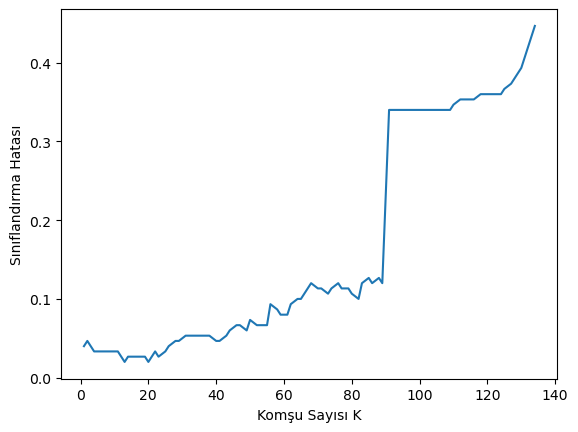

In [30]:
#---her k için sınıflandırma hatası hesapla---
MSE = [1 - x for x in cv_puanları]
#---en iyi k'yi (min. MSE) belirleme---
en_iyi_k = ks[MSE.index(min(MSE))]
print(f"En uygun komşu sayısı {en_iyi_k}")
#---sınıflandırma hatası vs k'yi çiz---
plt.plot(ks, MSE)
plt.xlabel('Komşu Sayısı K')
plt.ylabel('Sınıflandırma Hatası')
plt.show()

Önceki kod parçacığı aşağıdakini yazdırır:

    En uygun komşu sayısı 13

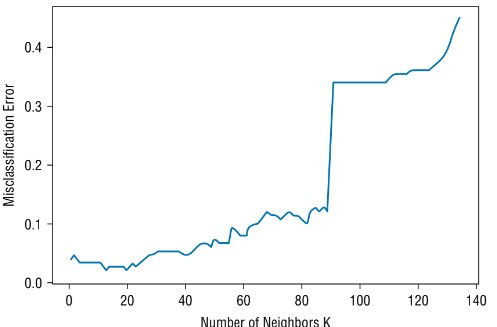

In [31]:
Image(filename='Figure-9.9.jpg')

**Şekil 9.9:** Her k için hata grafiği

Şekil 9.10, k = 13 olduğunda sınıflandırmayı göstermektedir.

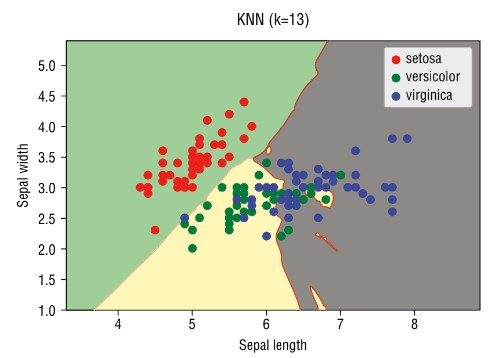

In [32]:
Image(filename='Figure-9.10.jpg')

**Şekil 9.10:** Optimal k değeri 13 olarak ayarlanmıştır

## Özet

Bu kitapta tartıştığımız dört algoritmadan biri olan KNN, en açıklayıcı olanlardan biri olarak kabul edilir. Bu bölümde, KNN'nin nasıl çalıştığını ve hataların hatalarının en aza indirildiği en uygun k'nın nasıl elde edileceğini öğrendiniz. Bir sonraki bölümde, yeni bir tür algoritma olan gözetimsiz öğrenme hakkında bilgi edineceksiniz. K-Means kullanarak kümeleme yaparak verilerinizdeki yapıları keşfetmeyi öğreneceksiniz.